### Assignment 1

Submission should be in a Jupyter note book (.ipynb)

1. Implement a function that converts a ```fixed<w, b>``` representation to a real number. Use two's compement for negative numbers. The function signature is 

   ```python
   def fromFixedPoint(w: int, b:int, bits:[int]) -> float:
   # w: width of the binary representation
   # b: binary point
   ```
   Test the following inputs
   ```python
   fromFixedPoint(10, 3, [0, 1, 0, 1, 1, 0, 0, 1, 1, 0])
   ```
   ```python
   fromFixedPoint(10, 5, [1, 0, 0, 1, 0, 1, 0, 1, 1, 1])
   ```
   ```python
   fromFixedPoint(8, 2, [1, 0, 1, 0, 1, 0, 1, 1])
   ```
   


In [28]:
def fromFixedPoint(w: int, b:int, bits: [int]) -> float:
    # v_min = -2 ** (w - 1 - b)
    # v_max = 2 ** (w - 1 - b) - 2 ** ( - b)
    # print(len(bits))

    # calculate first negative bit
    res = -2 ** (w - 1 - b) * bits[0]
    if len(bits) != w:
        print("Warning: length of bits does not match width")
    for idx, bit in zip(reversed(range(-b, w - 1 - b)), bits[1:]):
        res += bit * 2 ** (idx)
        # print(idx, bit, bit * 2 ** (idx), res)
    # print(res)
    return res

display(fromFixedPoint(10, 3, [0, 1, 0, 1, 1, 0, 0, 1, 1, 0]))
display(fromFixedPoint(10, 5, [1, 0, 0, 1, 0, 1, 0, 1, 1, 1]))
display(fromFixedPoint(8, 2, [1, 0, 1, 0, 1, 0, 1, 1]))
display(fromFixedPoint(8, 0, [0, 0, 0, 0, 1, 1, 0, 0]))

44.75

-13.28125

-21.25

12

2. Calculate the price of the following questions step by step using two step Cox Rox Rubinstein (CRR) Binomial tree

    a. European call option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 20%$
    
    b. European put option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 20%$
    
    c. European call option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 10%$
    
    d. European put option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 10%$
    
    What is the value of the portfolio that is long (a) and short (b)? How about the portfolio that long (c) and short (d)?

""" check put call parity """
    

In [1]:
from enum import Enum
import math
import matplotlib.pyplot as plt
import numpy as np


class PayoffType(str, Enum):
    Call = 'Call'
    Put = 'Put'
    BinaryCall = 'BinaryCall'
    BinaryPut = 'BinaryPut'

class EuropeanOption():
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        elif self.payoffType == PayoffType.BinaryCall:
            return 1.0 if S > self.strike else 0.0
        elif self.payoffType == PayoffType.BinaryPut:
            return 1.0 if S < self.strike else 0.0
        else:
            raise ValueError("Unknown payoff type")
    def valueAtNode(self, t, S, cont):
        if cont is None:
            return self.payoff(S)
        else:
            return cont

def crrBinomialG(S, r, vol, trade, n):
    t = trade.expiry / n
    b = math.exp(vol * vol * t+r*t) + math.exp(-r * t)
    u = (b + math.sqrt(b*b - 4)) / 2
    p = (math.exp(r * t) - (1/u)) / (u - 1/u)

    vs = [trade.payoff( S * u**(n-i-i) ) for i in range(n+1)]
    for i in range(n-1, -1, -1):
        for j in range(0, i+1):
            nodeS = S * u**(i-j-j)
            cont = math.exp(-r*t) * (p * vs[j] + (1-p) * vs[j+1])
            vs[j] = trade.valueAtNode(t*i, nodeS, cont)
    return vs[0]



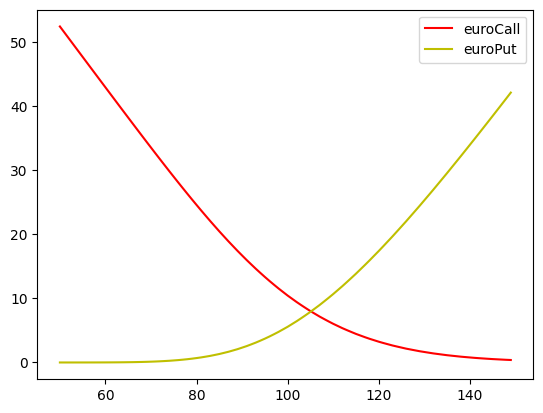

In [38]:
def crrBinomialGEur():
# testing binomial tree pricer with American Option
    euroPrc, amerPrc = [],  []
    S, r, vol = 100, 0.05, 0.2
    ks = range(50, 150)
    for k in ks:
        euroPrc.append(crrBinomialG(S, r, vol, EuropeanOption(1, float(k), PayoffType.Call), 300))
        # amerPrc.append(crrBinomialG(S, r, vol, AmericanOption(1, float(k), PayoffType.Call), 300))
    plt.plot(ks, euroPrc, 'r', label = 'euroCall')
    # plt.plot(ks, amerPrc, 'g', label = 'amerCall')
    euroPrc, amerPrc = [],  []
    for k in ks:
        euroPrc.append(crrBinomialG(S, r, vol, EuropeanOption(1, float(k), PayoffType.Put), 300))
        # amerPrc.append(crrBinomialG(S, r, vol, AmericanOption(1, float(k), PayoffType.Put), 300))
    plt.plot(ks, euroPrc, 'y', label = 'euroPut')
    # plt.plot(ks, amerPrc, 'b', label = 'euroPut')
    plt.legend()

crrBinomialGEur()

In [45]:
S, k, r, T = 100, 105, .03, 1
display(crrBinomialG(S, r, .2, EuropeanOption(T, float(k), PayoffType.Call), 2))
display(crrBinomialG(S, r, .2, EuropeanOption(T, float(k), PayoffType.Put), 2))
display(crrBinomialG(S, r, .1, EuropeanOption(T, float(k), PayoffType.Call), 2))
display(crrBinomialG(S, r, .1, EuropeanOption(T, float(k), PayoffType.Put), 2))

7.334893644625005

9.231674667218368

3.555283800757024

5.452064823350394

In [54]:
# by put call parity P+S-C=Ke^(-rt)
# C - P = Ke^(-rt) - S

C = crrBinomialG(S, r, .2, EuropeanOption(T, float(k), PayoffType.Call), 2)
P = crrBinomialG(S, r, .2, EuropeanOption(T, float(k), PayoffType.Put), 2)
display(-(P + S - C - k * math.exp(-r * T)) < 10**-16)
display(-(S - k * math.exp(-r * T)))

C = crrBinomialG(S, r, .1, EuropeanOption(T, float(k), PayoffType.Call), 2)
P = crrBinomialG(S, r, .1, EuropeanOption(T, float(k), PayoffType.Put), 2)

display(-(S - k * math.exp(-r * T)) < 10**-16)
display(-(S - k * math.exp(-r * T)))

True

1.896781022593359

False

1.896781022593359

3. Greeks measure the sensitivity of the price of derivatives to a change in underlying asset’s parameters. They are used for hedging and risk
management. The commonly used greeks are:
    * Delta $\Delta = \frac{\partial V}{\partial S}$: measures the rate of change of the option value with respect to changes in the underlying asset's price.
    * Gamma $\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S}$: measures the rate of change of delta with respect to changes in the underlying asset's price.
    * Vega: $v = \frac{\partial V}{\partial \sigma}$: measures the rate of change of the option value with respect to changes in the underlying asset's volatility.
    * Theta: $\theta = \frac{\partial V}{\partial t}$: the rate of change in the price of an option with respect to pricing time. Note that we normally use $t$ to represent pricing time, $T$ to represent expiry time, time to expiry in our pricer is $T-t$. In the implementation of the pricers that take time to expiry as an argument, we implicitly set pricing time to 0 (present).
    * Rho: the rate of change in the price of an option in response to a change in the interest rate.
    
  The greeks are normally not known in closed form since numerical pricers are used. They are approximated by finite differences:

  \begin{align}
    & \Delta = \frac{\partial V}{\partial S} \approx \frac{V(S + \Delta S) - V(S-\Delta S)}{2 \Delta S}, ~~~\Delta S = 0.1\% S \\
    & \Gamma = \frac{\partial V^2}{\partial S^2} \approx \frac{V(S + \Delta S) - 2V(S) + V(S-\Delta S)}{\Delta S^2} \\
    & v = \frac{\partial V}{\partial \sigma} \approx \frac{V(S, \sigma +\Delta \sigma) - V(S, \sigma -\Delta \sigma)}{2 \Delta \sigma } ~~~~~~~\Delta \sigma = 0.1\% \\
    & \theta = \frac{\partial V}{\partial t} \approx \frac{V(S, t+\Delta t, T) - V(S, t, T)}{\Delta t} ~~~~\Delta t = 0.004 \\
    & \rho = \frac{\partial V}{\partial r} \approx \frac{V(S, r+\Delta r) - V(S, r - \Delta r)}{2 \Delta r}  ~~~~~\Delta r = 0.0001
  \end{align}

  Implement a Greeks calculater for binomial tree pricer provided below. The signature of the greeks calculator is
      ```python
      def binomialGreeks(S, r, vol, T, strike, greekType) -> float
      ```
  Setting $S = 100, r = 0.03, vol = 0.2, t = 0, T = 1$, plot each greeks as a function of strike from 50 to 150. Play with different binomial models and see if there is any difference.
  
  Note that in practice, the greeks are rescaled with a pre-defined scaler, so that they give a sense of how much PV (Delta) changes with a typical move of the market. The rescaling is not incorporated in this exercise.


`try graphing gamma and make sure it matches yoru expectation of the bell curve`
`pick a gamma to make the curve as smooth as possible`
`plot all the graphs on one plot so you can compare`

In [2]:
# binomial pricer for exercise 3
import math
from enum import Enum

class PayoffType(Enum):
    Call = 0
    Put = 1
    
class EuropeanOption():
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        return continuation

class AmericanOption():
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        return max(self.payoff(S), continuation)

def crrCalib(r, vol, t):
    b = math.exp(vol * vol * t + r * t) + math.exp(-r * t)
    u = (b + math.sqrt(b * b - 4)) / 2
    p = (math.exp(r * t) - (1 / u)) / (u - 1 / u)
    return (u, 1/u, p)

def jrrnCalib(r, vol, t):
    u = math.exp((r - vol * vol / 2) * t + vol * math.sqrt(t))
    d = math.exp((r - vol * vol / 2) * t - vol * math.sqrt(t))
    p = (math.exp(r * t) - d) / (u - d)
    return (u, d, p)

def jreqCalib(r, vol, t):
    u = math.exp((r - vol * vol / 2) * t + vol * math.sqrt(t))
    d = math.exp((r - vol * vol / 2) * t - vol * math.sqrt(t))
    return (u, d, 1/2)

def tianCalib(r, vol, t):
    v = math.exp(vol * vol * t)
    u = 0.5 * math.exp(r * t) * v * (v + 1 + math.sqrt(v*v + 2*v - 3))
    d = 0.5 * math.exp(r * t) * v * (v + 1 - math.sqrt(v*v + 2*v - 3))
    p = (math.exp(r * t) - d) / (u - d)
    return (u, d, p)

def binomialPricer(S, r, vol, trade, n, calib):
    t = trade.expiry / n
    (u, d, p) = calib(r, vol, t)
    # set up the last time slice, there are n+1 nodes at the last time slice
    vs = [trade.payoff(S * u ** (n - i) * d ** i) for i in range(n + 1)]
    # iterate backward
    for i in range(n - 1, -1, -1):
        # calculate the value of each node at time slide i, there are i nodes
        for j in range(i + 1):
            nodeS = S * u ** (i - j) * d ** j
            continuation = math.exp(-r * t) * (vs[j] * p + vs[j + 1] * (1 - p))
            vs[j] = trade.valueAtNode(t * i, nodeS, continuation)
    return vs[0]

In [4]:
class greekType(str, Enum):
    delta = 'delta'
    gamma = 'gamma'
    vega = 'vega'
    theta = 'theta'
    rho = 'rho'

def binomialGreeks(S, r, vol, T, strike, greekType, calib) -> float:
    n = 500
    payoff = PayoffType.Call

    dS = 0.01 * S
    dS2 = .005 * S
    dvol = 0.1 * 1e-2
    dt = .004
    dr = .0001

    if greekType == 'delta':
        price_up = binomialPricer(S + dS, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        price_down = binomialPricer(S - dS, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        return (price_up - price_down) / (2 * dS)
    elif greekType == 'gamma':
        price = binomialPricer(S, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        price_up = binomialPricer(S + dS2, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        price_down = binomialPricer(S - dS2, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        return (price_up - 2 * price + price_down) / (dS2 * dS2)
    elif greekType == 'vega':
        price_up = binomialPricer(S, r, vol + dvol, EuropeanOption(T, float(strike), payoff), n, calib)
        price_down = binomialPricer(S, r, vol - dvol, EuropeanOption(T, float(strike), payoff), n, calib)
        return (price_up - price_down) / (2 * dvol)
    elif greekType == 'theta':
        price_up = binomialPricer(S, r, vol, EuropeanOption(T - dt, float(strike), payoff), n, calib)
        price_down = binomialPricer(S, r, vol, EuropeanOption(T + dt, float(strike), payoff), n, calib)
        return (price_up - price_down) / (2 * dt)
    elif greekType == 'rho':
        price_up = binomialPricer(S, r + dr, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        price_down = binomialPricer(S, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
        return (price_up - price_down) / (2 * dr)
    else:
        raise ValueError("Unknown greek type: ", greekType)


S, r, vol, T = 100, .03, .2, 1
# display(binomialPricer(S, r, vol, EuropeanOption(1, float(k), PayoffType.Call), 300, crrCalib))

# strike = 100
# display(
#     binomialGreeks(S, r, vol, T, strike, 'delta'),
#     binomialGreeks(S, r, vol, T, strike, 'gamma') ,
#     binomialGreeks(S, r, vol, T, strike, 'vega') ,
#     binomialGreeks(S, r, vol, T, strike, 'theta') ,
#     binomialGreeks(S, r, vol, T, strike, 'rho') 
#     )

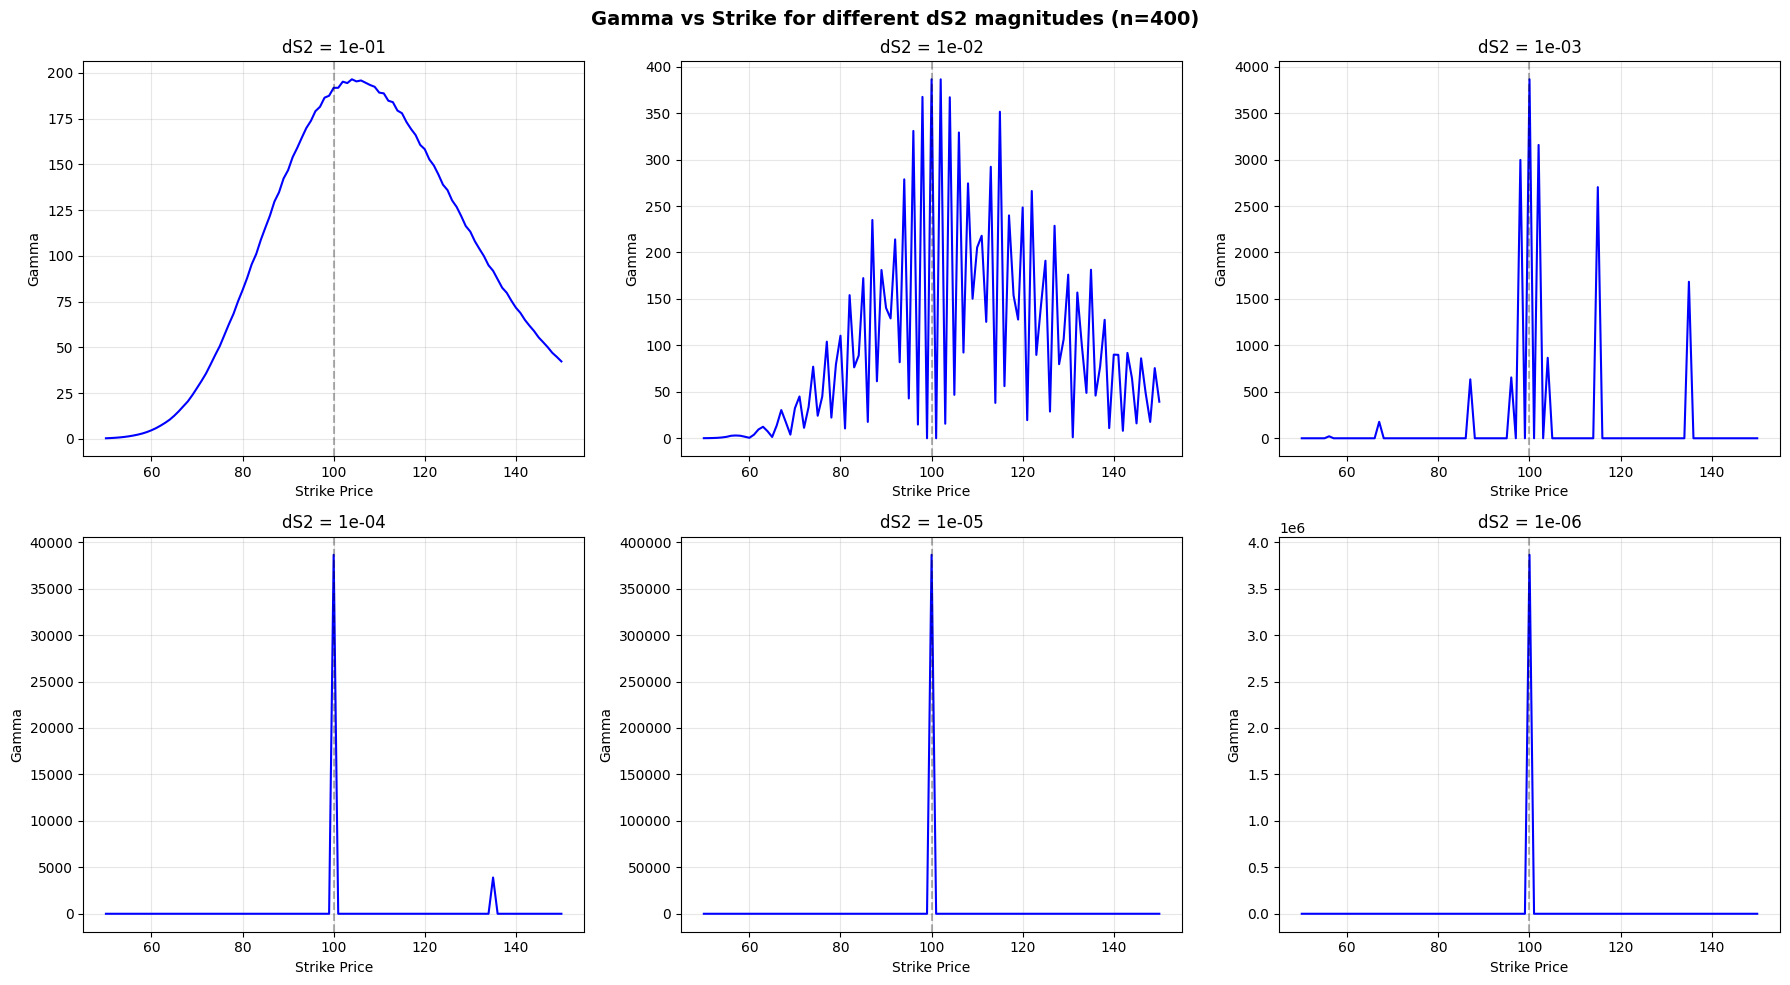

In [13]:
def binomialGamma(S, r, vol, T, strike, n, dS2, calib=crrCalib) -> float:
    """Compute gamma using central finite difference with configurable n and dS2."""
    payoff = PayoffType.Call
    price = binomialPricer(S, r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
    price_up = binomialPricer(S * (1+dS2), r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
    price_down = binomialPricer(S * (1-dS2), r, vol, EuropeanOption(T, float(strike), payoff), n, calib)
    return (price_up - 2 * price + price_down) / (dS2 * dS2)


def plot_gamma_vs_dS2(S, r, vol, T, n=500, calib=crrCalib):
    """Plot gamma vs strike for different magnitudes of dS2."""
    dS2_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    ks = np.arange(50, 151, 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, dS2 in enumerate(dS2_values):
        ax = axes[idx]
        gammas = [binomialGamma(S, r, vol, T, k, n, dS2, calib) for k in ks]
        ax.plot(ks, gammas, 'b-', linewidth=1.5)
        ax.set_xlabel('Strike Price')
        ax.set_ylabel('Gamma')
        ax.set_title(f'dS2 = {dS2:.0e}')
        ax.grid(True, alpha=0.3)
        ax.axvline(x=S, color='black', linestyle='--', alpha=0.3)

    plt.suptitle(f'Gamma vs Strike for different dS2 magnitudes (n={n})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


S, r, vol, T = 100, 0.03, 0.2, 1
plot_gamma_vs_dS2(S, r, vol, T, n=400, calib=crrCalib)

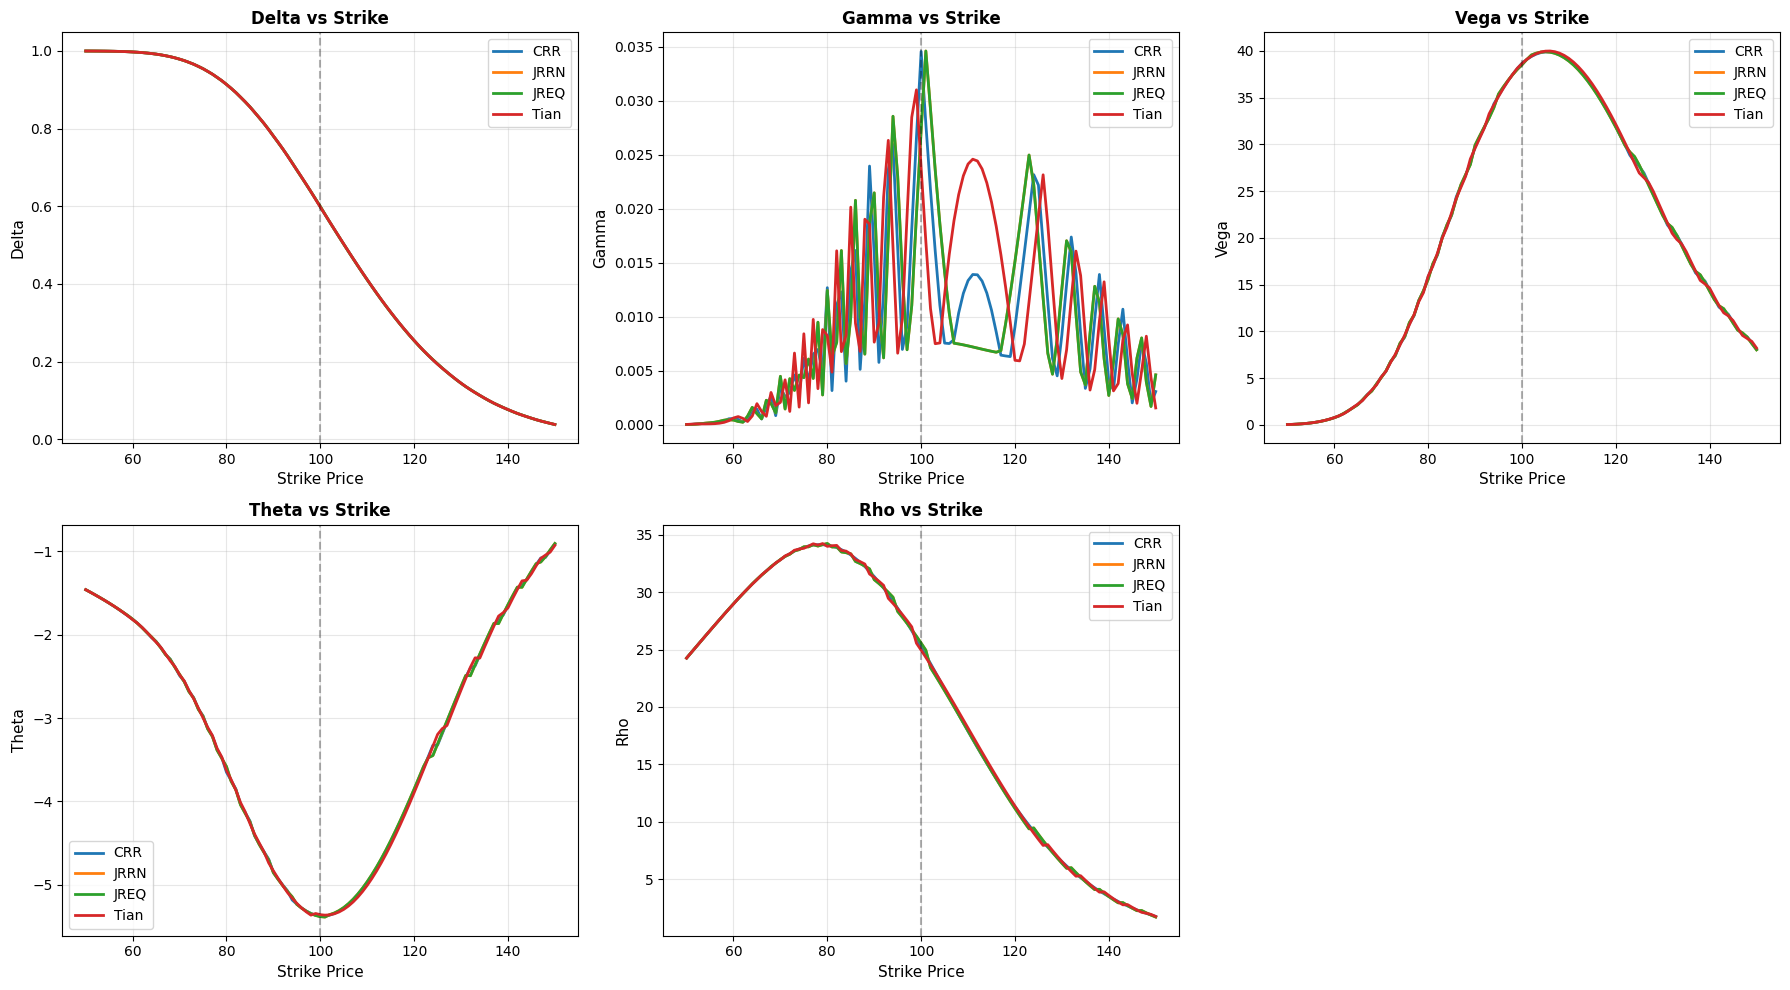

In [112]:
# Parameters
S, r, vol, T = 100, 0.03, 0.2, 1
ks = np.arange(50, 151, 1) 

# Calibration methods to compare
calibrations = {
    'CRR': crrCalib,
    'JRRN': jrrnCalib,
    'JREQ': jreqCalib,
    'Tian': tianCalib
}

# Greek types to plot
greek_types = ['delta', 'gamma', 'vega', 'theta', 'rho']

# Create subplots for all Greeks
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, greek in enumerate(greek_types):
    ax = axes[idx]
    
    # Calculate and plot each calibration method
    for calib_name, calib_func in calibrations.items():
        greek_values = [binomialGreeks(S, r, vol, T, k, greek, calib_func) for k in ks]
        ax.plot(ks, greek_values, label=calib_name, linewidth=2)
    
    ax.set_xlabel('Strike Price', fontsize=11)
    ax.set_ylabel(greek.capitalize(), fontsize=11)
    ax.set_title(f'{greek.capitalize()} vs Strike', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=S, color='black', linestyle='--', alpha=0.3, label=f'S={S}')

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.show()


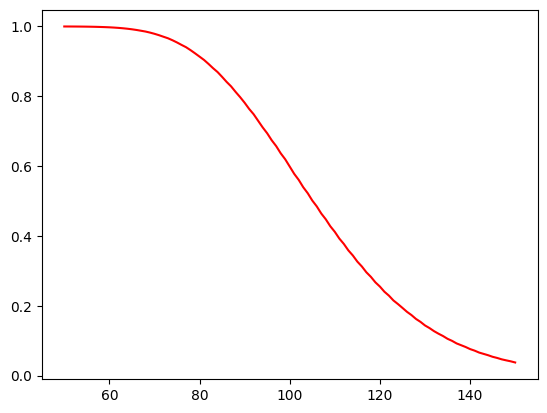

In [92]:
deltas = []
ks = range(50, 151)
for k in ks:
    deltas.append(binomialGreeks(S, r, vol, T, k, 'delta'))

plt.plot(ks, deltas, 'r', label = 'delta')

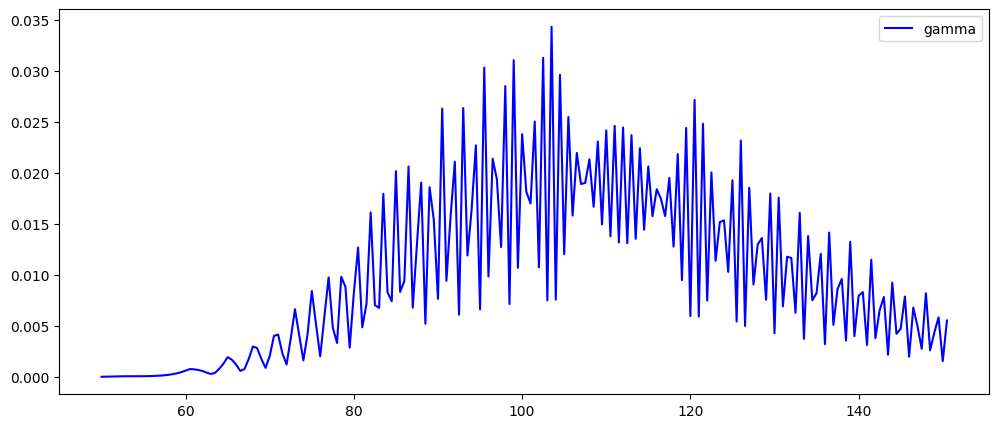

In [109]:
ks = np.arange(50, 151, 0.5)  # More granular strikes
gammas = [binomialGreeks(S, r, vol, T, k, 'gamma') for k in ks]

plt.figure(figsize=(12, 5))
plt.plot(ks, gammas, 'b', label='gamma')
plt.legend()
plt.show()

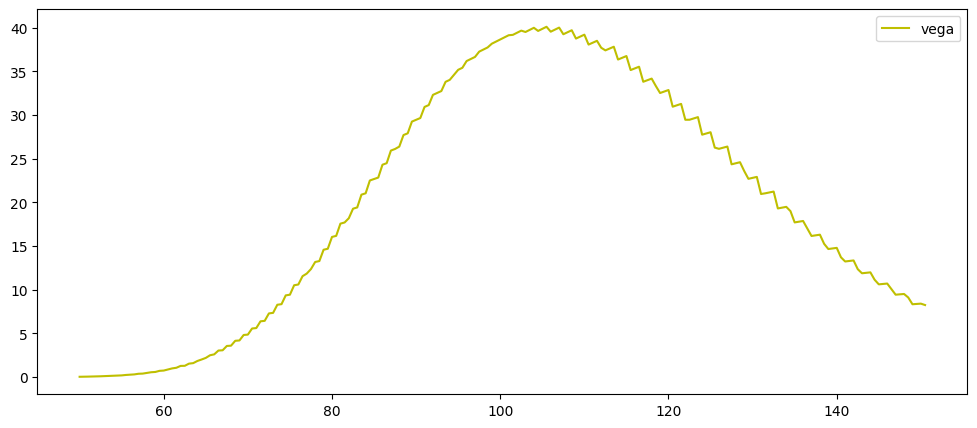

In [103]:
ks = np.arange(50, 151, 0.5)  # More granular strikes
vegas = [binomialGreeks(S, r, vol, T, k, 'vega') for k in ks]

plt.figure(figsize=(12, 5))
plt.plot(ks, vegas, 'y', label='vega')
plt.legend()
plt.show()

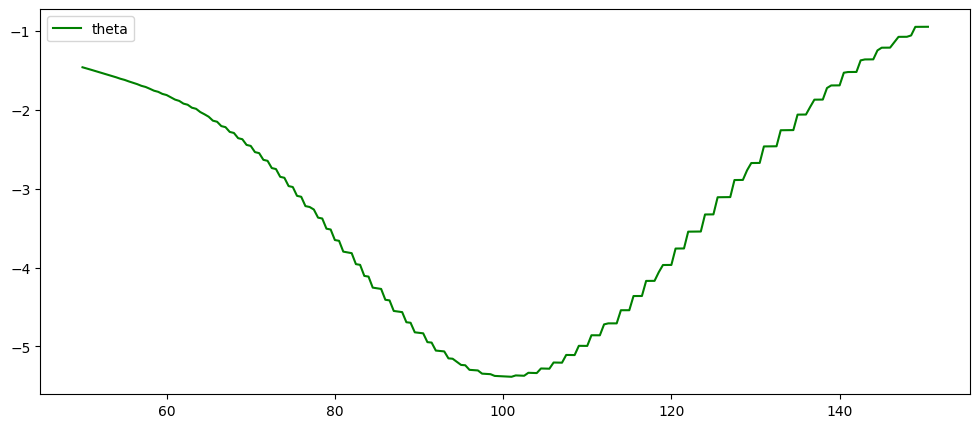

In [105]:
ks = np.arange(50, 151, 0.5)  # More granular strikes
thetas = [binomialGreeks(S, r, vol, T, k, 'theta') for k in ks]

plt.figure(figsize=(12, 5))
plt.plot(ks, thetas, 'g', label='theta')
plt.legend()
plt.show()

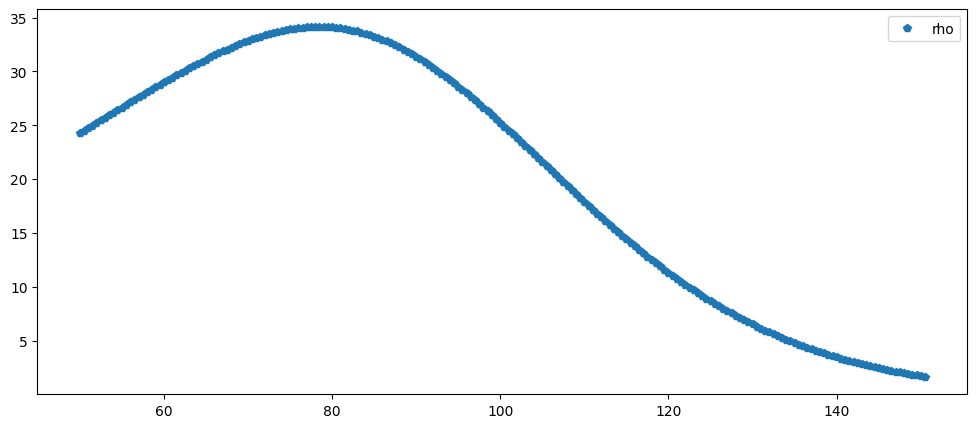

In [106]:
ks = np.arange(50, 151, 0.5)  # More granular strikes
gammas = [binomialGreeks(S, r, vol, T, k, 'rho') for k in ks]

plt.figure(figsize=(12, 5))
plt.plot(ks, gammas, 'p', label='rho')
plt.legend()
plt.show()

4. Impement a trinomial tree 

Instead of taking the parameter $\lambda$ in our example code, this function takes a discontinuity K and anchors a tree node to K by tuning $\lambda$ inside the pricer.
Note that there are many ways to adjust $\lambda$, one example is to construct the tree with $\lambda = \sqrt{3}$ first, find the node closest to $K$, then adjust $\lambda$ such that the node falls on $K$, but you are free to define your own way to achieve this.

Plot the pricing errors of this trinomial tree pricer with the market and strike below, for number of tree steps from 10 to 300 (similar to our binomial tree test cases).
Use a European Call option and a Binary Call option as test trades.

`expect error term to be monotonocially decreasing`

In [143]:
def trinomialPricer(S, r, q, vol, trade, n, lmda):
    t = trade.expiry / n
    u = math.exp(lmda * vol * math.sqrt(t))
    mu = r - q
    pu = 1 / 2 / lmda / lmda + (mu - vol * vol / 2) / 2 / lmda / vol * math.sqrt(t)
    pd = 1 / 2 / lmda / lmda - (mu - vol * vol / 2) / 2 / lmda / vol * math.sqrt(t)
    pm = 1 - pu - pd

    vs = [trade.payoff(S*u**(n-i)) for i in range(2*n+1)]

    for i in range(n-1, -1,-1):
        for j in range(2*i+1):
            nodeS = S * u**(i-j)
            continuation = math.exp(-r*t) * (vs[j] * pu +  vs[j+1] * pm + vs[j+2] * pd)
            vs[j] = trade.valueAtNode(t*i, nodeS, continuation)
    return vs[0]


def trinomialPricerAnchor(S, r, q, vol, trade, n, K):
    dt = trade.expiry / n
    lmda = math.sqrt(3)
    display(f'lambda initial is {lmda:.5f}')

    # calculate distance from K to S
    anchor_index = n - round(math.log(K/S) / (vol * math.sqrt(dt) * lmda))
    if anchor_index < 0 and anchor_index > 2*n:
        return "Anchor index out of bounds"
    elif (n- anchor_index)< 1:
        lmda = math.log(K / S) / (vol * math.sqrt(dt) * (n+1-anchor_index))
    else: 
        lmda = math.log(K / S) / (vol * math.sqrt(dt) * (n-anchor_index))
    display(f'lambda adjusted is {lmda:.5f}')

    return trinomialPricer(S, r, q, vol, trade, n, lmda)





S, r, vol, K = 100, 0.01, 0.2, 105
display(trinomialPricerAnchor(S, r, 0.0, vol, EuropeanOption(1, float(K), PayoffType.Call), 100, K))
display(trinomialPricer(S, r, 0.0, vol, EuropeanOption(1, float(K), PayoffType.Call), 100, math.sqrt(3)))

'lambda initial is 1.73205'

'lambda adjusted is 2.43951'

6.248419713908292

6.3060080944000605

In [145]:
from binomial import *


def testTrinomial():
    S, r, vol = 100, 0.01, 0.2
    opt = EuropeanOption(1, 105, PayoffType.Call)
    bsprc = bsPrice(S, r, vol, opt.expiry, opt.strike, opt.payoffType)
    print("bsPrice = \t ", bsprc)

    prc = trinomialPricer(S, r, 0, vol, opt, 500, math.sqrt(3))
    print("Trinomial tree Price = \t ", prc)
    n = 300
    crrErrs = [math.log(abs(binomialPricer(S, r, vol, opt, i, crrCalib) - bsprc)) for i in range(1, n)]
    jrrnErrs = [math.log(abs(binomialPricer(S, r, vol, opt, i, jrrnCalib) - bsprc)) for i in range(1, n)]
    jreqErrs = [math.log(abs(binomialPricer(S, r, vol, opt, i, jreqCalib) - bsprc)) for i in range(1, n)]
    tianErrs = [math.log(abs(binomialPricer(S, r, vol, opt, i, tianCalib) - bsprc)) for i in range(1, n)]
    triErrs = [math.log(abs(trinomialPricer(S, r, 0, vol, opt, i, math.sqrt(3)) - bsprc)) for i in range(1, n)]
    plt.plot(range(1, n), crrErrs, label="crr")
    plt.plot(range(1, n), jrrnErrs, label="jrrn")
    plt.plot(range(1, n), jreqErrs, label="jreq")
    plt.plot(range(1, n), tianErrs, label="tian")
    plt.plot(range(1, n), triErrs, label="trinomial")
    plt.legend()
    plt.show()

In [ ]:
testTrinomial()

1.7320508075688772

European Call BS Price = 	 6.297254539086019
Binary Call BS Price = 	 0.4579714222553879

Calculating European Call errors...
Calculating Binary Call errors...
Calculating Binary Call errors...


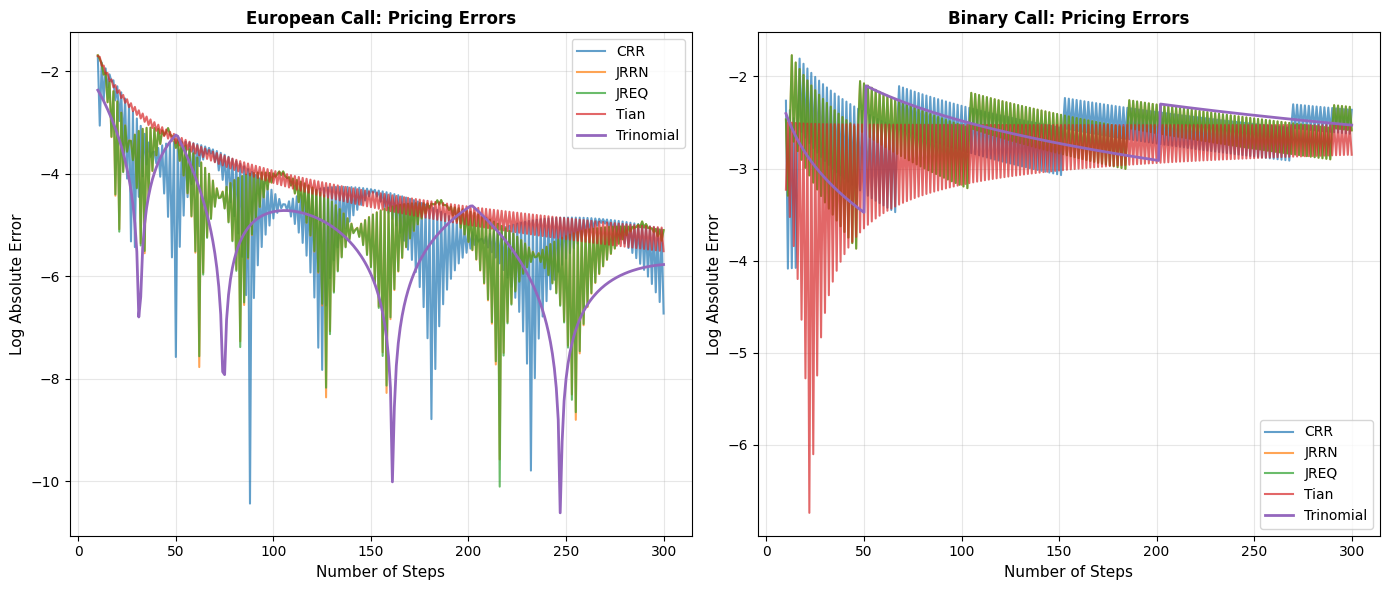

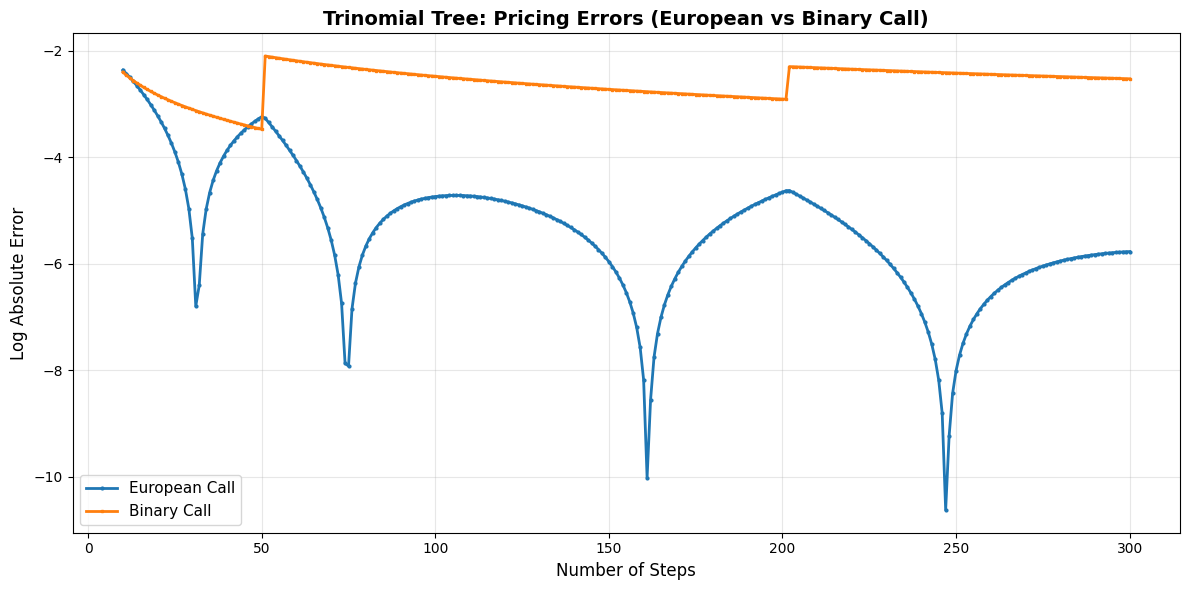

'Trinomial with Anchor:'

'lambda initial is 1.73205'

'lambda adjusted is 2.43951'

6.248419713908292

'Trinomial standard:'

6.3060080944000605

In [147]:
def testTrinomialWithBinary():
    S, r, vol, K = 100, 0.01, 0.2, 105
    T = 1.0
    
    # European Call option
    opt_european = EuropeanOption(T, K, PayoffType.Call)
    bsprc_european = bsPrice(S, r, vol, opt_european.expiry, opt_european.strike, opt_european.payoffType)
    print("European Call BS Price = \t", bsprc_european)
    
    # Binary Call option
    opt_binary = EuropeanOption(T, K, PayoffType.BinaryCall)
    bsprc_binary = bsPrice(S, r, vol, opt_binary.expiry, opt_binary.strike, opt_binary.payoffType)
    print("Binary Call BS Price = \t", bsprc_binary)
    
    # Range of tree steps
    n_range = range(10, 301)
    
    # Calculate errors for European Call
    print("\nCalculating European Call errors...")
    crrErrs_euro = [math.log(abs(binomialPricer(S, r, vol, opt_european, i, crrCalib) - bsprc_european)) for i in n_range]
    jrrnErrs_euro = [math.log(abs(binomialPricer(S, r, vol, opt_european, i, jrrnCalib) - bsprc_european)) for i in n_range]
    jreqErrs_euro = [math.log(abs(binomialPricer(S, r, vol, opt_european, i, jreqCalib) - bsprc_european)) for i in n_range]
    tianErrs_euro = [math.log(abs(binomialPricer(S, r, vol, opt_european, i, tianCalib) - bsprc_european)) for i in n_range]
    triErrs_euro = [math.log(abs(trinomialPricer(S, r, 0, vol, opt_european, i, math.sqrt(3)) - bsprc_european)) for i in n_range]
    
    # Calculate errors for Binary Call
    print("Calculating Binary Call errors...")
    crrErrs_binary = [math.log(abs(binomialPricer(S, r, vol, opt_binary, i, crrCalib) - bsprc_binary)) for i in n_range]
    jrrnErrs_binary = [math.log(abs(binomialPricer(S, r, vol, opt_binary, i, jrrnCalib) - bsprc_binary)) for i in n_range]
    jreqErrs_binary = [math.log(abs(binomialPricer(S, r, vol, opt_binary, i, jreqCalib) - bsprc_binary)) for i in n_range]
    tianErrs_binary = [math.log(abs(binomialPricer(S, r, vol, opt_binary, i, tianCalib) - bsprc_binary)) for i in n_range]
    triErrs_binary = [math.log(abs(trinomialPricer(S, r, 0, vol, opt_binary, i, math.sqrt(3)) - bsprc_binary)) for i in n_range]
    
    # Plot European Call errors
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(n_range, crrErrs_euro, label="CRR", alpha=0.7)
    plt.plot(n_range, jrrnErrs_euro, label="JRRN", alpha=0.7)
    plt.plot(n_range, jreqErrs_euro, label="JREQ", alpha=0.7)
    plt.plot(n_range, tianErrs_euro, label="Tian", alpha=0.7)
    plt.plot(n_range, triErrs_euro, label="Trinomial", linewidth=2)
    plt.xlabel('Number of Steps', fontsize=11)
    plt.ylabel('Log Absolute Error', fontsize=11)
    plt.title('European Call: Pricing Errors', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot Binary Call errors
    plt.subplot(1, 2, 2)
    plt.plot(n_range, crrErrs_binary, label="CRR", alpha=0.7)
    plt.plot(n_range, jrrnErrs_binary, label="JRRN", alpha=0.7)
    plt.plot(n_range, jreqErrs_binary, label="JREQ", alpha=0.7)
    plt.plot(n_range, tianErrs_binary, label="Tian", alpha=0.7)
    plt.plot(n_range, triErrs_binary, label="Trinomial", linewidth=2)
    plt.xlabel('Number of Steps', fontsize=11)
    plt.ylabel('Log Absolute Error', fontsize=11)
    plt.title('Binary Call: Pricing Errors', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Separate plot for just trinomial comparison
    plt.figure(figsize=(12, 6))
    plt.plot(n_range, triErrs_euro, label="European Call", linewidth=2, marker='o', markersize=2)
    plt.plot(n_range, triErrs_binary, label="Binary Call", linewidth=2, marker='s', markersize=2)
    plt.xlabel('Number of Steps', fontsize=12)
    plt.ylabel('Log Absolute Error', fontsize=12)
    plt.title('Trinomial Tree: Pricing Errors (European vs Binary Call)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run the test
testTrinomialWithBinary()

# Original test for verification
S, r, vol, K = 100, 0.01, 0.2, 105
display("Trinomial with Anchor:")
display(trinomialPricerAnchor(S, r, 0.0, vol, EuropeanOption(1, float(K), PayoffType.Call), 100, K))
display("Trinomial standard:")
display(trinomialPricer(S, r, 0.0, vol, EuropeanOption(1, float(K), PayoffType.Call), 100, math.sqrt(3)))